In [106]:
import numpy as np 
import pandas as pd

In [107]:
from sqlalchemy import create_engine

In [108]:
pizza = pd.read_csv(r"C:\Users\bhagr\OneDrive\Documents\sql_pizza_pro\pizza_sales\pizzas.csv")

In [109]:
pizza_type = pd.read_csv(r"C:\Users\bhagr\OneDrive\Documents\sql_pizza_pro\pizza_sales\pizza_types.csv",encoding = 'latin-1')

In [110]:
orders = pd.read_csv(r"C:\Users\bhagr\OneDrive\Documents\sql_pizza_pro\pizza_sales\orders.csv")

In [111]:
order_details = pd.read_csv(r"C:\Users\bhagr\OneDrive\Documents\sql_pizza_pro\pizza_sales\order_details.csv")

In [112]:
pizza.head()

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [113]:
pizza.shape

(96, 4)

In [114]:
pizza.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pizza_id       96 non-null     object 
 1   pizza_type_id  96 non-null     object 
 2   size           96 non-null     object 
 3   price          96 non-null     float64
dtypes: float64(1), object(3)
memory usage: 3.1+ KB


In [115]:
pizza.isnull().sum()

pizza_id         0
pizza_type_id    0
size             0
price            0
dtype: int64

In [116]:
pizza[pizza.duplicated()]

,pizza_id,pizza_type_id,size,price


In [117]:
pizza_type.head()

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


In [118]:
pizza_type.shape

(32, 4)

In [119]:
pizza_type.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   pizza_type_id  32 non-null     object
 1   name           32 non-null     object
 2   category       32 non-null     object
 3   ingredients    32 non-null     object
dtypes: object(4)
memory usage: 1.1+ KB


In [120]:
pizza_type.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
dtype: bool

In [121]:
orders.head()

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [122]:
orders.shape

(21350, 3)

In [123]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21350 entries, 0 to 21349
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   order_id  21350 non-null  int64 
 1   date      21350 non-null  object
 2   time      21350 non-null  object
dtypes: int64(1), object(2)
memory usage: 500.5+ KB


In [124]:
# converting data datatype:

In [125]:
orders['date'] = pd.to_datetime(orders['date'])

In [126]:
orders['time'] = pd.to_datetime(orders['time']).dt.time

C:\Users\bhagr\AppData\Local\Temp\ipykernel_12604\356924125.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  orders['time'] = pd.to_datetime(orders['time']).dt.time


In [127]:
# extract year,month from date column

In [128]:
orders['month_name'] = pd.to_datetime(orders.date).dt.month_name()

In [129]:
orders['year'] = pd.to_datetime(orders.date).dt.year

In [130]:
orders.head()

,order_id,date,time,month_name,year
0,1,2015-01-01,11:38:36,January,2015
1,2,2015-01-01,11:57:40,January,2015
2,3,2015-01-01,12:12:28,January,2015
3,4,2015-01-01,12:16:31,January,2015
4,5,2015-01-01,12:21:30,January,2015


In [131]:
order_details.head()

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


In [132]:
order_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   order_details_id  48620 non-null  int64 
 1   order_id          48620 non-null  int64 
 2   pizza_id          48620 non-null  object
 3   quantity          48620 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [133]:
order_details.shape

(48620, 4)

In [134]:
# merge tables:

In [135]:
pizza.head(2)

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75


In [136]:
pizza_type.head(2)

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."


In [137]:
p_details = pizza.merge(pizza_type,how = 'inner',on = 'pizza_type_id')

In [138]:
p_details.head()

,pizza_id,pizza_type_id,size,price,name,category,ingredients
0,bbq_ckn_s,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,bbq_ckn_m,bbq_ckn,M,16.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
2,bbq_ckn_l,bbq_ckn,L,20.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
3,cali_ckn_s,cali_ckn,S,12.75,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
4,cali_ckn_m,cali_ckn,M,16.75,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."


In [139]:
p_details.shape

(96, 7)

In [140]:
#1. What are the unique pizza categories?

In [141]:
p_details['category'].unique()

array(['Chicken', 'Classic', 'Supreme', 'Veggie'], dtype=object)

In [142]:
p_details['category'].nunique()

4

In [143]:
p_details['category'].value_counts()

category
Veggie     27
Classic    26
Supreme    25
Chicken    18
Name: count, dtype: int64

In [144]:
#What are the different sizes available?
p_details['size'].unique()

array(['S', 'M', 'L', 'XL', 'XXL'], dtype=object)

In [145]:
p_details['size'].value_counts().sort_values(ascending = False)

size
S      32
M      31
L      31
XL      1
XXL     1
Name: count, dtype: int64

In [146]:
# 2.What is the average price of pizzas?

In [147]:
# total_revenue
p_details['price'].sum() 

np.float64(1578.3)

In [148]:
# top 3 category heighest revenue:
p_details.groupby('category')['price'].sum().sort_values(ascending = False).head(3)

category
Veggie     432.45
Classic    424.70
Supreme    419.65
Name: price, dtype: float64

In [149]:
# avg price each pizza:
p_details.groupby('category')['price'].mean().round()

category
Chicken    17.0
Classic    16.0
Supreme    17.0
Veggie     16.0
Name: price, dtype: float64

In [150]:
# Group by size → find mean & total price

In [151]:
# heighest sales by size:
p_details.groupby('size')['price'].sum().sort_values(ascending = False).head(2)

size
L    620.70
M    495.75
Name: price, dtype: float64

In [152]:
p_details.groupby('size')['price'].mean().sort_values(ascending = False).round()

size
XXL    36.0
XL     26.0
L      20.0
M      16.0
S      13.0
Name: price, dtype: float64

In [153]:
# Create a new column → price category (Low/Medium/High)

In [154]:
bins = [0,13,20,35]
labels = ['Low','Medium','High']
p_details['Price_category'] = pd.cut(p_details['price'],bins=bins,labels=labels)

In [155]:
p_details['Price_category']

0        Low
1     Medium
2       High
3        Low
4     Medium
       ...  
91    Medium
92      High
93       Low
94    Medium
95      High
Name: Price_category, Length: 96, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']

In [156]:
p_details.price.describe()

count    96.000000
mean     16.440625
std       4.090266
min       9.750000
25%      12.500000
50%      16.250000
75%      20.250000
max      35.950000
Name: price, dtype: float64

In [157]:
# def price_cat(price):
#     if price < 13:
#         return 'LOW'
#     elif price <= 20:
#         return 'MEDIUM'
#     else:
#         return 'HIGH'
# p_details['price_category'] = p_details.price.apply(price_cat)

In [158]:
# Extract top 10 most common ingredients

In [159]:
p_details['ingredients'].value_counts().head(10)

ingredients
Kalamata Olives, Feta Cheese, Tomatoes, Garlic, Beef Chuck Roast, Red Onions                    5
Barbecued Chicken, Red Peppers, Green Peppers, Tomatoes, Red Onions, Barbecue Sauce             3
Chicken, Red Onions, Red Peppers, Mushrooms, Asiago Cheese, Alfredo Sauce                       3
Chicken, Artichoke, Spinach, Garlic, Jalapeno Peppers, Fontina Cheese, Gouda Cheese             3
Chicken, Tomatoes, Red Peppers, Red Onions, Jalapeno Peppers, Corn, Cilantro, Chipotle Sauce    3
Chicken, Pineapple, Tomatoes, Red Peppers, Thai Sweet Chilli Sauce                              3
Bacon, Pepperoni, Italian Sausage, Chorizo Sausage                                              3
Chicken, Tomatoes, Red Peppers, Spinach, Garlic, Pesto Sauce                                    3
Pepperoni, Mushrooms, Red Onions, Red Peppers, Bacon                                            3
Sliced Ham, Pineapple, Mozzarella Cheese                                                        3
Name: co

In [160]:
# Which pizzas have the maximum number of ingredients?

In [161]:
p_details['ingredient_count'] = p_details['ingredients'].str.split(',').apply(len)

In [162]:
p_details['ingredient_count'].max()

8

In [163]:
p_details[p_details['ingredient_count'] == p_details['ingredient_count'].max()]

,pizza_id,pizza_type_id,size,price,name,category,ingredients,Price_category,ingredient_count
12,southw_ckn_s,southw_ckn,S,12.75,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja...",Low,8
13,southw_ckn_m,southw_ckn,M,16.75,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja...",Medium,8
14,southw_ckn_l,southw_ckn,L,20.75,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja...",High,8
66,spinach_supr_s,spinach_supr,S,12.50,The Spinach Supreme Pizza,Supreme,"Spinach, Red Onions, Pepperoni, Tomatoes, Arti...",Low,8
67,spinach_supr_m,spinach_supr,M,16.50,The Spinach Supreme Pizza,Supreme,"Spinach, Red Onions, Pepperoni, Tomatoes, Arti...",Medium,8
68,spinach_supr_l,spinach_supr,L,20.75,The Spinach Supreme Pizza,Supreme,"Spinach, Red Onions, Pepperoni, Tomatoes, Arti...",High,8
84,mexicana_s,mexicana,S,12.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",Low,8
85,mexicana_m,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",Medium,8
86,mexicana_l,mexicana,L,20.25,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",High,8
93,veggie_veg_s,veggie_veg,S,12.00,The Vegetables + Vegetables Pizza,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper...",Low,8


In [164]:
p_details.head(3)

,pizza_id,pizza_type_id,size,price,name,category,ingredients,Price_category,ingredient_count
0,bbq_ckn_s,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",Low,6
1,bbq_ckn_m,bbq_ckn,M,16.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",Medium,6
2,bbq_ckn_l,bbq_ckn,L,20.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",High,6


<Axes: xlabel='category'>

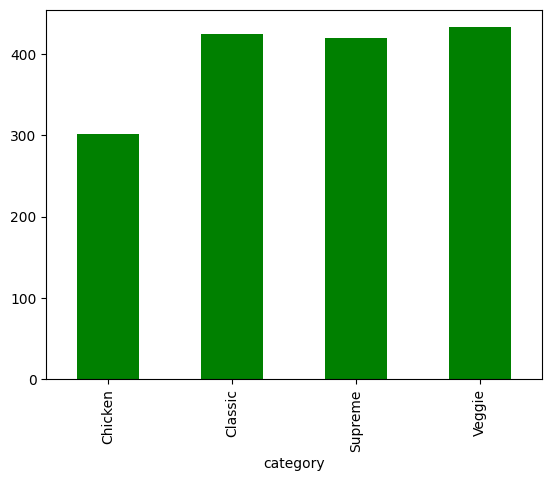

In [165]:
p_details.groupby('category')['price'].sum().plot(kind = 'bar',color = 'green')

<Axes: >

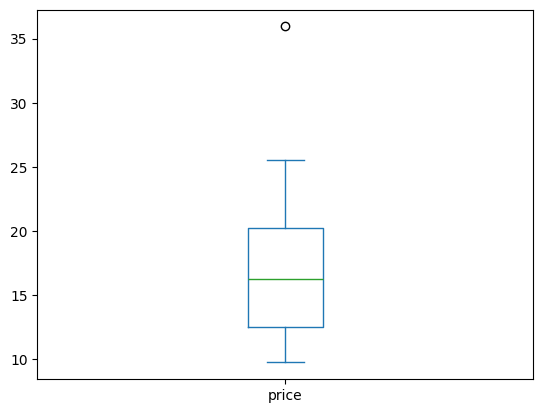

In [166]:
p_details.price.plot(kind = 'box')

<Axes: ylabel='price'>

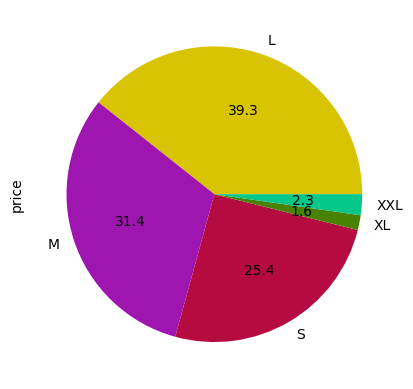

In [167]:
p_details.groupby('size').price.sum().plot(kind = 'pie',autopct = '%.1f',colors = ['#d9c404','#9e15b0','#b50b41','#478203','#04c789'])


In [168]:
# merging orders and order_details

In [169]:
orders.head(3)

,order_id,date,time,month_name,year
0,1,2015-01-01,11:38:36,January,2015
1,2,2015-01-01,11:57:40,January,2015
2,3,2015-01-01,12:12:28,January,2015


In [170]:
order_details.head(3)

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1


In [171]:
ord_details = orders.merge(order_details,how = 'inner',on = 'order_id')

In [172]:
ord_details.head(3)

,order_id,date,time,month_name,year,order_details_id,pizza_id,quantity
0,1,2015-01-01,11:38:36,January,2015,1,hawaiian_m,1
1,2,2015-01-01,11:57:40,January,2015,2,classic_dlx_m,1
2,2,2015-01-01,11:57:40,January,2015,3,five_cheese_l,1


In [173]:
p_details.head(3)

,pizza_id,pizza_type_id,size,price,name,category,ingredients,Price_category,ingredient_count
0,bbq_ckn_s,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",Low,6
1,bbq_ckn_m,bbq_ckn,M,16.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",Medium,6
2,bbq_ckn_l,bbq_ckn,L,20.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",High,6


In [174]:
data = p_details.merge(ord_details,how = 'inner', on = 'pizza_id')

In [175]:
data.head(2)

,pizza_id,pizza_type_id,size,price,name,category,ingredients,Price_category,ingredient_count,order_id,date,time,month_name,year,order_details_id,quantity
0,bbq_ckn_s,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",Low,6,6,2015-01-01,12:29:36,January,2015,11,1
1,bbq_ckn_s,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",Low,6,102,2015-01-02,17:54:04,January,2015,239,1


In [176]:
data.shape

(48620, 16)

In [177]:
data.columns

Index(['pizza_id', 'pizza_type_id', 'size', 'price', 'name', 'category',
       'ingredients', 'Price_category', 'ingredient_count', 'order_id', 'date',
       'time', 'month_name', 'year', 'order_details_id', 'quantity'],
      dtype='object')

In [178]:
data['revenue'] = data['price'] * data['quantity']

In [179]:
data['revenue'].sum()

np.float64(817860.05)

In [180]:
# Most expansive Pizza:

In [181]:
data[['price','name']].sort_values(ascending = False,by = 'price').head()

,price,name
25374,35.95,The Greek Pizza
25373,35.95,The Greek Pizza
25372,35.95,The Greek Pizza
25393,35.95,The Greek Pizza
25366,35.95,The Greek Pizza


In [182]:
pd.pivot_table(data, values='revenue', index='size', columns='category', aggfunc='sum')

category,Chicken,Classic,Supreme,Veggie
size,,,,
L,102339.0,74518.50,94258.5,104202.70
M,65224.5,60581.75,66475.0,57101.00
S,28356.0,69870.25,47463.5,32386.75
XL,NaN,14076.00,NaN,NaN
XXL,NaN,1006.60,NaN,NaN


<Axes: xlabel='size'>

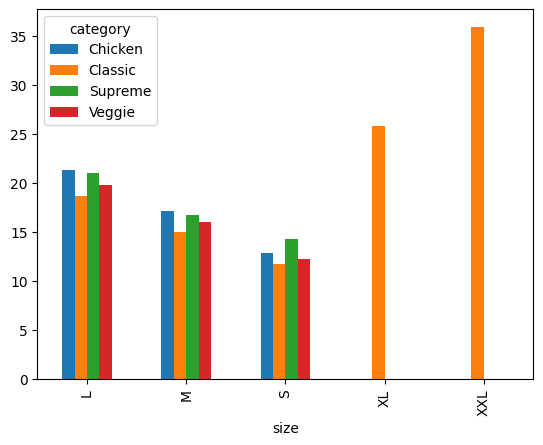

In [183]:
pd.pivot_table(data,values = 'revenue',index = 'size',columns = 'category',aggfunc ='mean').plot(kind = 'bar')

In [184]:
data.head(2)

,pizza_id,pizza_type_id,size,price,name,category,ingredients,Price_category,ingredient_count,order_id,date,time,month_name,year,order_details_id,quantity,revenue
0,bbq_ckn_s,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",Low,6,6,2015-01-01,12:29:36,January,2015,11,1,12.75
1,bbq_ckn_s,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",Low,6,102,2015-01-02,17:54:04,January,2015,239,1,12.75


In [185]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   pizza_id          48620 non-null  object        
 1   pizza_type_id     48620 non-null  object        
 2   size              48620 non-null  object        
 3   price             48620 non-null  float64       
 4   name              48620 non-null  object        
 5   category          48620 non-null  object        
 6   ingredients       48620 non-null  object        
 7   Price_category    48592 non-null  category      
 8   ingredient_count  48620 non-null  int64         
 9   order_id          48620 non-null  int64         
 10  date              48620 non-null  datetime64[ns]
 11  time              48620 non-null  object        
 12  month_name        48620 non-null  object        
 13  year              48620 non-null  int32         
 14  order_details_id  4862

In [186]:
##---List the top 5 most ordered pizza types along with their quantities.

In [187]:
data[['pizza_type_id','quantity']].value_counts().sort_values(ascending = False).head(5)

pizza_type_id  quantity
classic_dlx    1           2382
pepperoni      1           2321
hawaiian       1           2319
bbq_ckn        1           2316
thai_ckn       1           2260
Name: count, dtype: int64

In [188]:
##Join the necessary tables to find the total quantity of each pizza category catogery.

In [189]:
data.groupby('category').sum('quantity')['quantity'].sort_values(ascending = False)

category
Classic    14888
Supreme    11987
Veggie     11649
Chicken    11050
Name: quantity, dtype: int64

In [ ]:
##---Join relevant tables to find the category-wise distribution of pizzas.

In [221]:
data[['category','name']].value_counts()

category  name                                      
Classic   The Classic Deluxe Pizza                      2416
Chicken   The Barbecue Chicken Pizza                    2372
Classic   The Hawaiian Pizza                            2370
          The Pepperoni Pizza                           2369
Chicken   The Thai Chicken Pizza                        2315
          The California Chicken Pizza                  2302
Supreme   The Spicy Italian Pizza                       1887
          The Sicilian Pizza                            1887
Chicken   The Southwest Chicken Pizza                   1885
Veggie    The Four Cheese Pizza                         1850
Supreme   The Italian Supreme Pizza                     1849
Classic   The Big Meat Pizza                            1811
Veggie    The Vegetables + Vegetables Pizza             1510
          The Mexicana Pizza                            1456
Classic   The Napolitana Pizza                          1451
Veggie    The Spinach and Feta P

In [190]:
from sqlalchemy import create_engine

In [191]:
username = 'postgres'
password = 'bhagyaraj123'
host = 'localhost'
port = '5432'
database = 'pizza_project'

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

table_name1 = 'pizza'
pizza.to_sql(
    table_name1,
    engine,
    if_exists = 'replace',
    index = False
)
table_name2 = 'p_details'
p_details.to_sql(
    table_name2,
    engine,
    if_exists = 'replace',
    index = False
)

96

In [192]:
username = 'postgres'
password = 'bhagyaraj123'
host = 'localhost'
port = 5432
database = 'pizza_project'

engine = create_engine(f'postgresql+psycopg2://{username}:{password}@{host}/{database}')

table_name3 = 'orders'
table_name4 = 'order_details'

orders.to_sql(
    table_name3,
    engine,
    if_exists = 'replace',
    index = False
)

order_details.to_sql(
    table_name4,
    engine,
    if_exists = 'replace',
    index = False
)
print('creates tables..')

creates tables..
